NAME : MOHD RAZA, ROLL NO : 35, SECTION : B

# Experiment No. 8
## Customer Churn Prediction using Decision Tree Classification

**Aim:** To build and evaluate a Decision Tree Classification model for predicting customer
churn using a real-world dataset and analyze the factors influencing customer retention.

### Step 1: Import Required Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                              recall_score, f1_score, classification_report,
                              ConfusionMatrixDisplay)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
print("Libraries imported successfully.")

Libraries imported successfully.


### Step 2: Load the Dataset
Replace `DATA_PATH` with your actual **Telco Customer Churn Dataset** CSV
(e.g. `WA_Fn-UseC_-Telco-Customer-Churn.csv` from Kaggle/IBM) if you have one. If the file
isn't found, a synthetic dataset with similar structure (demographics, account info,
services, and a Churn label) is generated automatically so the notebook runs end-to-end.

In [7]:
import os

DATA_PATH = "/content/WA_Fn-UseC_-Telco-Customer-Churn.csv"   # <-- change this to your dataset path
df = pd.read_csv(DATA_PATH)
print(f"Loaded real dataset from {DATA_PATH}, shape = {df.shape}")
df.head()

Loaded real dataset from /content/WA_Fn-UseC_-Telco-Customer-Churn.csv, shape = (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Step 3: Data Preprocessing

In [8]:
print("Dataset info:\n")
df.info()

print("\nMissing values per column:\n")
print(df.isnull().sum())

# TotalCharges is sometimes stored as string with blanks in the real Telco dataset
if df["TotalCharges"].dtype == object:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df = df.dropna(subset=["TotalCharges"])
df = df.drop_duplicates()

if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

print(f"\nCleaned dataset shape: {df.shape}")
print(f"\nChurn distribution:\n{df['Churn'].value_counts()}")

Dataset info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-

### Step 4: Encode Categorical Variables

In [9]:
df_encoded = df.copy()

categorical_cols = df_encoded.select_dtypes(include="object").columns.tolist()
categorical_cols = [c for c in categorical_cols if c != "Churn"]

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

# Encode target variable
target_encoder = LabelEncoder()
df_encoded["Churn"] = target_encoder.fit_transform(df_encoded["Churn"])  # No=0, Yes=1

print(f"Encoded categorical columns: {categorical_cols}")
df_encoded.head()

Encoded categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


### Step 5: Train-Test Split

In [10]:
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"\nTrain churn rate: {y_train.mean():.2%}")
print(f"Test churn rate: {y_test.mean():.2%}")

Training set size: (5625, 19)
Testing set size: (1407, 19)

Train churn rate: 26.58%
Test churn rate: 26.58%


### Step 6: Train the Decision Tree Classifier

In [11]:
dt_model = DecisionTreeClassifier(
    criterion="gini",       # or "entropy"
    max_depth=5,             # limit depth to reduce overfitting
    min_samples_leaf=20,
    random_state=42
)

dt_model.fit(X_train, y_train)
print("Decision Tree trained successfully.")
print(f"Tree depth: {dt_model.get_depth()}")
print(f"Number of leaves: {dt_model.get_n_leaves()}")

Decision Tree trained successfully.
Tree depth: 5
Number of leaves: 31


### Step 7: Predict on Test Data

In [12]:
y_pred = dt_model.predict(X_test)
y_pred_proba = dt_model.predict_proba(X_test)[:, 1]

results_df = X_test.copy()
results_df["Actual"] = y_test.values
results_df["Predicted"] = y_pred
results_df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual,Predicted
974,0,0,1,1,59,1,0,0,0,2,...,2,2,2,2,1,1,75.95,4542.35,0,0
619,0,0,0,0,7,1,2,1,0,2,...,0,0,0,0,1,0,78.55,522.95,0,1
4289,0,0,0,0,54,1,0,2,1,1,...,1,1,1,2,0,3,20.10,1079.45,0,0
3721,0,0,0,0,2,1,0,2,1,1,...,1,1,1,0,0,3,20.65,38.70,1,0
4533,0,0,1,0,71,1,2,1,0,2,...,0,2,2,2,1,0,105.15,7555.00,0,0
445,0,0,0,0,60,1,2,1,0,2,...,0,2,2,0,1,2,105.90,6396.45,1,0
5898,0,0,1,1,33,1,2,2,1,1,...,1,1,1,1,0,1,24.15,800.30,0,0
3387,0,0,0,0,7,1,0,2,1,1,...,1,1,1,0,0,3,20.65,155.90,0,0
1346,0,0,1,1,14,1,2,1,0,0,...,0,0,2,0,1,2,87.25,1258.60,1,1
5690,1,0,0,0,72,0,1,0,2,0,...,2,2,2,2,1,1,61.20,4390.25,0,0


### Step 8: Evaluate the Model

In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("MODEL EVALUATION METRICS")
print("-" * 40)
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-Score : {f1:.3f}")
print("\nFull classification report:")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

MODEL EVALUATION METRICS
----------------------------------------
Accuracy : 0.781
Precision: 0.605
Recall   : 0.508
F1-Score : 0.552

Full classification report:
              precision    recall  f1-score   support

          No       0.83      0.88      0.86      1033
         Yes       0.61      0.51      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



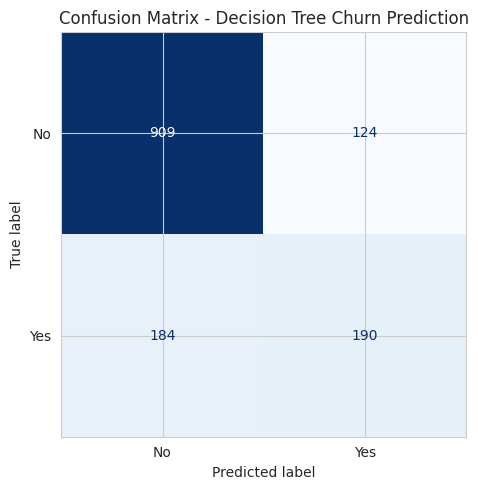

True Negatives (correctly predicted 'No Churn'): 909
False Positives (predicted churn, actually stayed): 124
False Negatives (predicted stay, actually churned): 184
True Positives (correctly predicted 'Churn'): 190


In [14]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_encoder.classes_)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Decision Tree Churn Prediction")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly predicted 'No Churn'): {tn}")
print(f"False Positives (predicted churn, actually stayed): {fp}")
print(f"False Negatives (predicted stay, actually churned): {fn}")
print(f"True Positives (correctly predicted 'Churn'): {tp}")

### Step 9: Visualize the Decision Tree

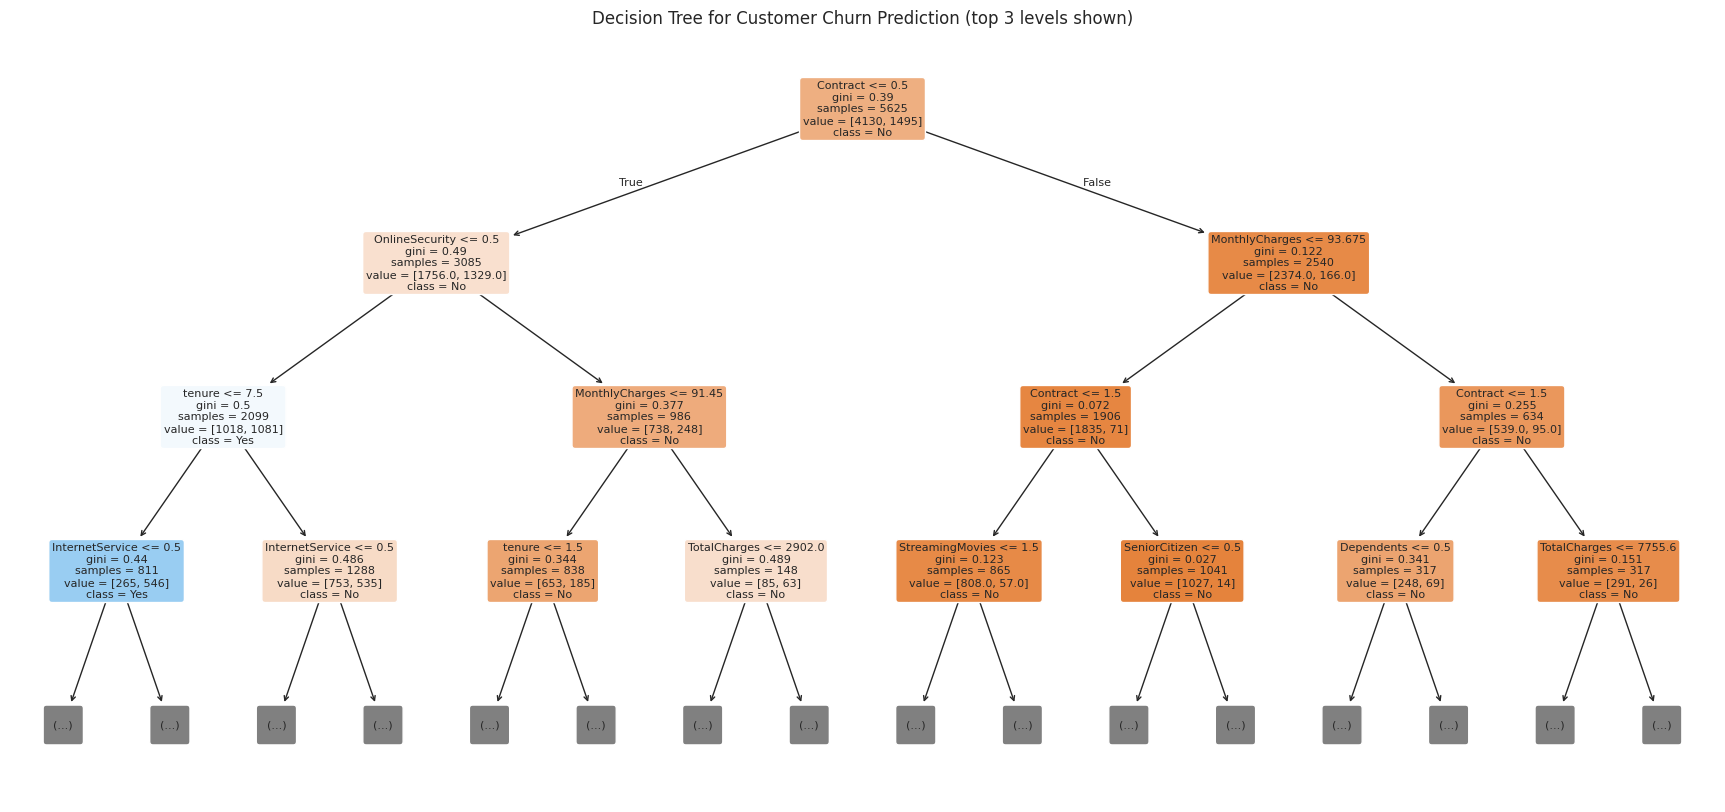

In [15]:
plt.figure(figsize=(22, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=target_encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3   # show top levels for readability; remove to see full tree
)
plt.title("Decision Tree for Customer Churn Prediction (top 3 levels shown)")
plt.show()

### Step 10: Feature Importance — Key Factors Driving Churn

/tmp/ipykernel_1575/51757304.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(10), x="Importance", y="Feature", palette="viridis")


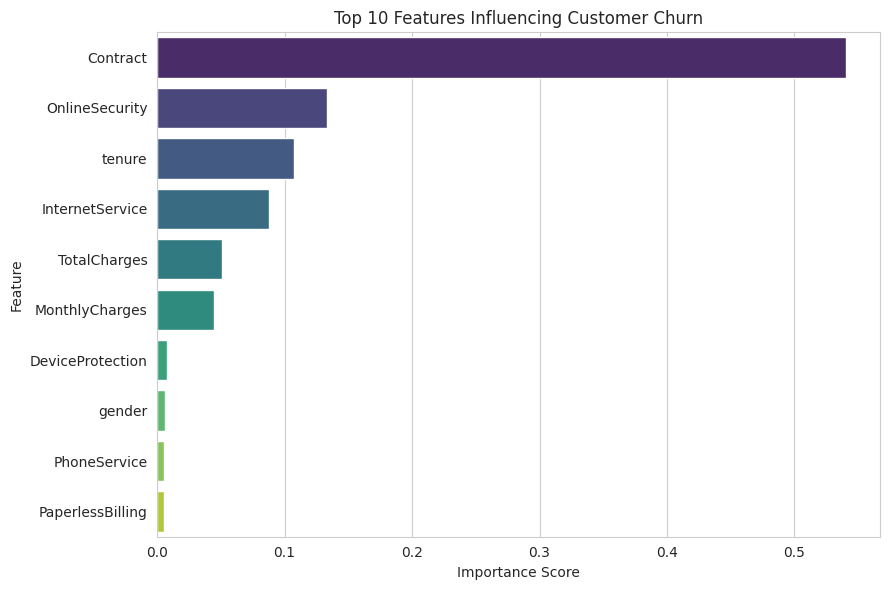

,Feature,Importance
14,Contract,0.540101
8,OnlineSecurity,0.133601
4,tenure,0.107411
7,InternetService,0.087682
18,TotalCharges,0.050752
17,MonthlyCharges,0.044861
10,DeviceProtection,0.007742
0,gender,0.006285
5,PhoneService,0.005335
15,PaperlessBilling,0.005184


In [16]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=feature_importance.head(10), x="Importance", y="Feature", palette="viridis")
plt.title("Top 10 Features Influencing Customer Churn")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

feature_importance.head(10)

### Step 11: Business Insights & Retention Strategy Recommendations
Run the cell below for an automated summary based on the model's findings.

In [17]:
top_features = feature_importance.head(3)["Feature"].tolist()

print("CHURN PREDICTION - BUSINESS SUMMARY")
print("-" * 45)
print(f"Model Accuracy: {accuracy:.1%}  |  Precision: {precision:.1%}  |  Recall: {recall:.1%}  |  F1: {f1:.1%}")
print(f"\nTop factors driving churn (by feature importance): {', '.join(top_features)}")
print("\nRecommended retention strategies:")
print("- Target customers on month-to-month contracts with incentives to switch to")
print("  longer-term (1-2 year) contracts, which historically show much lower churn.")
print("- Proactively reach out to customers within their first 12 months of tenure,")
print("  since new customers are typically at the highest churn risk.")
print("- Review pricing/value perception for customers with high monthly charges,")
print("  e.g. offer bundled discounts or loyalty pricing.")
print("- Use the model's churn probability scores to prioritize retention outreach")
print("  (e.g., call center follow-ups) for the highest-risk customers first.")

CHURN PREDICTION - BUSINESS SUMMARY
---------------------------------------------
Model Accuracy: 78.1%  |  Precision: 60.5%  |  Recall: 50.8%  |  F1: 55.2%

Top factors driving churn (by feature importance): Contract, OnlineSecurity, tenure

Recommended retention strategies:
- Target customers on month-to-month contracts with incentives to switch to
  longer-term (1-2 year) contracts, which historically show much lower churn.
- Proactively reach out to customers within their first 12 months of tenure,
  since new customers are typically at the highest churn risk.
- Review pricing/value perception for customers with high monthly charges,
  e.g. offer bundled discounts or loyalty pricing.
- Use the model's churn probability scores to prioritize retention outreach
  (e.g., call center follow-ups) for the highest-risk customers first.
